# E-Commerce Sales Intelligence Analysis
### TheLook E-Commerce Full Pipeline Analysis

---

## Overview

This notebook presents a full analytical deep-dive into TheLook E-Commerce, a fashion retail dataset spanning **2019–2026** with over **180,000 order items** across **100,000 customers** in **16 countries**.

The data was ingested from `bigquery-public-data.thelook_ecommerce` using a Python + GCS + BigQuery pipeline, transformed through a dbt model layer (staging -> marts), and analysed here using Pandas, Matplotlib, and Seaborn.

### Analytical Questions Answered

**Revenue & Product Performance**
- Which product categories and departments drive the most revenue?
- How has monthly revenue trended, and what does MoM growth look like?
- Which categories are most profitable after accounting for cost?

**Geography & Acquisition**
- Which countries generate the most revenue?
- Which traffic/acquisition channels bring in the most revenue and the highest-value customers?

**Customer Health**
- What does the customer lifetime value (LTV) distribution look like?
- Who are the top customers by spend?
- What proportion of customers have churned?
- How well do cohorts retain over time?
- How concentrated is revenue among top customers?

---

> **Note on revenue figures:** All revenue calculations exclude **Cancelled**, **Returned**, and **Processing** order items, as these represent transactions where no payment was collected or was refunded. This ensures all monetary figures reflect realised revenue only.

## Setup
Import libraries, load credentials, and extract mart tables from BigQuery.

In [1]:
from google.cloud import bigquery
from dotenv import load_dotenv, find_dotenv
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

In [2]:
# Load credentials from .env file
load_dotenv(find_dotenv())

# Initialise BigQuery client
client = bigquery.Client(project=os.getenv("BQ_PROJECT"))

# Format all floats with commas and 2 decimal places throughout the notebook
pd.options.display.float_format = '{:,.2f}'.format

# Extract mart tables
# fct_orders: one row per order item, enriched with product and customer dimensions
fct_orders = client.query("""
    SELECT * FROM `career-practice.marts.fct_orders`
""").to_dataframe()

# dim_customers: one row per customer with aggregated LTV metrics
dim_customers = client.query("""
    SELECT * FROM `career-practice.marts.dim_customers`
""").to_dataframe()

# Filter to completed and shipped orders only, excludes cancelled, returned, and processing items
# This ensures all revenue figures reflect realised revenue
completed_orders = fct_orders[fct_orders['order_status'].isin(['Complete', 'Shipped'])].copy()

In [3]:
# Preview fct_orders schema and sample rows
fct_orders.head()

,order_item_id,order_id,user_id,product_id,item_status,sale_price,created_at,num_of_item,order_status,product_name,category,department,brand,cost,retail_price,full_name,country,traffic_source
0,159352,109974,88007,14235,Complete,0.02,2023-02-28 11:30:27+00:00,2,Complete,Indestructable Aluminum Aluma Wallet - RED,Accessories,Women,marshal,0.01,0.02,Catherine Boone,Brasil,Organic
1,111480,76910,61598,14235,Shipped,0.02,2020-09-08 07:31:21+00:00,4,Shipped,Indestructable Aluminum Aluma Wallet - RED,Accessories,Women,marshal,0.01,0.02,Vickie Williams,United Kingdom,Search
2,163569,112887,90316,14235,Processing,0.02,2021-08-11 08:30:32+00:00,1,Processing,Indestructable Aluminum Aluma Wallet - RED,Accessories,Women,marshal,0.01,0.02,Kaitlyn Jones,United States,Search
3,12052,8328,6650,14235,Cancelled,0.02,2026-05-25 19:18:49+00:00,2,Cancelled,Indestructable Aluminum Aluma Wallet - RED,Accessories,Women,marshal,0.01,0.02,Kathryn Martin,China,Search
4,69050,47531,38017,14235,Processing,0.02,2025-12-01 15:07:12+00:00,2,Processing,Indestructable Aluminum Aluma Wallet - RED,Accessories,Women,marshal,0.01,0.02,Sheila Adams,China,Search


In [4]:
# Preview dim_customers schema and sample rows
dim_customers.head()

,customer_id,customer_name,customer_email,customer_country,customer_age,total_spend,total_orders,avg_order_value,first_order_date,last_order_date,days_since_last_order
0,72158,Heather Townsend,heathertownsend@example.org,Australia,26,0.00,0,0.00,NaT,NaT,<NA>
1,50486,Emily Johnson,emilyjohnson@example.org,Australia,70,0.00,0,0.00,NaT,NaT,<NA>
2,23962,Lisa Thompson,lisathompson@example.org,Australia,15,0.00,0,0.00,NaT,NaT,<NA>
3,72802,Colleen Manning,colleenmanning@example.org,Australia,30,0.00,0,0.00,NaT,NaT,<NA>
4,45137,Steven Douglas,stevendouglas@example.net,Australia,35,0.00,0,0.00,NaT,NaT,<NA>


---
## Part 1: Revenue & Product Performance

This section answers: *where does revenue come from, and how is it trending?*

We look at revenue broken down by product category, department, and analyse the monthly revenue trend with month-over-month growth to understand the business trajectory.

In [5]:
# Top 10 product categories by realised revenue (completed + shipped orders only)
# Ranked 1–10 for readability
rev_product_category = (completed_orders
    .groupby('category')['sale_price']
    .agg(total_revenue='sum')
    .sort_values(by='total_revenue', ascending=False)
    .reset_index())
rev_product_category.index = range(1, len(rev_product_category) + 1)
rev_product_category.head(10)

,category,total_revenue
1,Outerwear & Coats,"727,796.91"
2,Jeans,"672,257.79"
3,Sweaters,"452,904.47"
4,Fashion Hoodies & Sweatshirts,"358,263.20"
5,Suits & Sport Coats,"357,782.88"
6,Swim,"355,671.42"
7,Sleep & Lounge,"309,572.14"
8,Shorts,"291,229.93"
9,Tops & Tees,"269,897.84"
10,Dresses,"255,569.78"


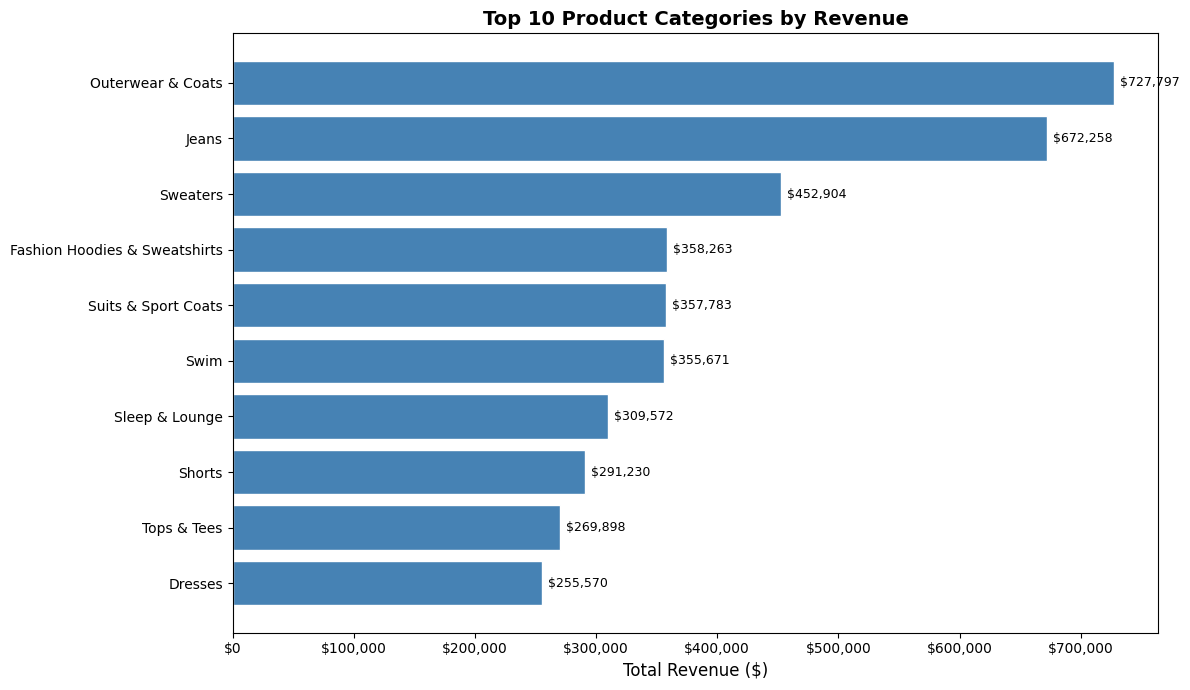

In [6]:
# Horizontal bar chart
top10 = rev_product_category.head(10).sort_values('total_revenue', ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top10['category'], top10['total_revenue'], color='steelblue', edgecolor='white')

# Add value labels to the right of each bar
for bar in bars:
    ax.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
            f'${bar.get_width():,.0f}', va='center', fontsize=9)

ax.set_title('Top 10 Product Categories by Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Revenue ($)', fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

### Finding: Outerwear & Coats leads all categories

**Outerwear & Coats** and **Jeans** are the clear top two revenue-generating categories, together accounting for a disproportionate share of total revenue. This is consistent with fashion retail patterns where high-ticket outerwear items drive revenue even at lower volumes.

**Business implication:** Inventory planning and promotional spend should prioritise these top categories. A supply disruption in Outerwear & Coats would have an outsized impact on total revenue.

In [7]:
# Revenue split by department (Men vs Women)
# Note: This dataset only has two departments: Men and Women
rev_department = (completed_orders
    .groupby('department')['sale_price']
    .agg(total_revenue='sum')
    .sort_values(by='total_revenue', ascending=False)
    .reset_index())
rev_department.index = range(1, len(rev_department) + 1)
rev_department

,department,total_revenue
1,Men,"3,139,997.93"
2,Women,"2,792,310.17"


### Finding: Men's department edges Women's in revenue

Men's generates approximately 12.5% more revenue than Women's (3.14M vs 2.79M). The split is relatively balanced, suggesting neither department is being neglected. With only two departments, the more interesting breakdown is at the category level above.

In [8]:
# Monthly revenue trend with MoM growth %
# Extract month and year from created_at for grouping
completed_orders['month'] = completed_orders['created_at'].dt.month
completed_orders['year'] = completed_orders['created_at'].dt.year

rev_month_year = (completed_orders
    .groupby(['year', 'month'])['sale_price']
    .agg(monthly_revenue='sum')
    .reset_index())

# Create a proper date column for clean x-axis formatting
rev_month_year['date'] = pd.to_datetime(rev_month_year[['year', 'month']].assign(day=1))

# MoM growth: (current - previous) / previous * 100
# First month will be NaN (no previous month to compare to)
rev_month_year['prev_monthly_revenue'] = rev_month_year['monthly_revenue'].shift(1)
rev_month_year['MoM_growth'] = (
    (rev_month_year['monthly_revenue'] - rev_month_year['prev_monthly_revenue'])
    / rev_month_year['prev_monthly_revenue'] * 100
).round(2)

rev_month_year[['date', 'monthly_revenue', 'MoM_growth']].tail(12)

,date,monthly_revenue,MoM_growth
77,2025-06-01,"130,311.27",-2.11
78,2025-07-01,"141,076.16",8.26
79,2025-08-01,"144,641.87",2.53
80,2025-09-01,"150,492.62",4.04
81,2025-10-01,"163,901.68",8.91
82,2025-11-01,"174,724.76",6.60
83,2025-12-01,"183,233.98",4.87
84,2026-01-01,"210,186.14",14.71
85,2026-02-01,"199,646.11",-5.01
86,2026-03-01,"241,259.42",20.84


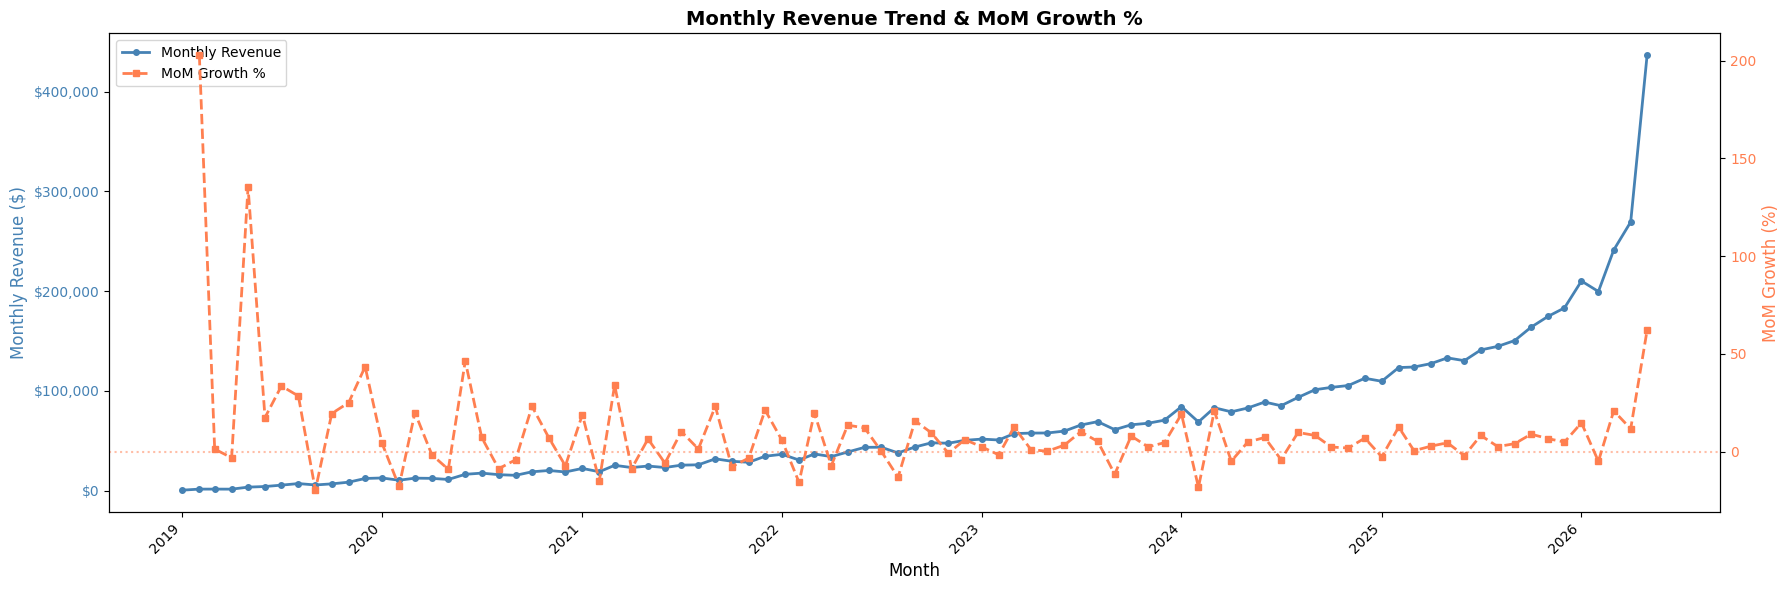

In [9]:
# Dual-axis line chart: revenue (left axis) + MoM growth % (right axis)
fig, ax1 = plt.subplots(figsize=(18, 6))

# Primary axis: monthly revenue
ax1.plot(rev_month_year['date'], rev_month_year['monthly_revenue'],
         color='steelblue', linewidth=2, marker='o', markersize=4, label='Monthly Revenue')
ax1.set_ylabel('Monthly Revenue ($)', color='steelblue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Secondary axis: MoM growth %
ax2 = ax1.twinx()
ax2.plot(rev_month_year['date'], rev_month_year['MoM_growth'],
         color='coral', linewidth=2, linestyle='--', marker='s', markersize=4, label='MoM Growth %')
ax2.set_ylabel('MoM Growth (%)', color='coral', fontsize=12)
ax2.tick_params(axis='y', labelcolor='coral')
ax2.axhline(y=0, color='coral', linestyle=':', alpha=0.5)  # zero reference line

ax1.set_xlabel('Month', fontsize=12)
fig.autofmt_xdate(rotation=45)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

plt.title('Monthly Revenue Trend & MoM Growth %', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Finding: Strong and consistent revenue growth since 2019

Monthly revenue shows a clear upward trajectory across the full 2019–2026 period, accelerating sharply in 2025–2026. MoM growth is volatile early on (2019–2020) as the customer base was small and individual months had outsized swings, but stabilises into a consistent 5–15% monthly growth band through 2023–2025.

The recent acceleration in 2026 is particularly notable, recent cohorts (2024–2025) are larger and their month-0 volumes are significantly higher than earlier cohorts, which flows through to total monthly revenue.

**Business implication:** The business is in a strong growth phase. The priority should be converting this revenue growth into retained customers, which the cohort analysis below examines.

---
## Part 2: Profitability Analysis

Revenue alone doesn't tell the full story. This section examines **gross profit** (sale price minus cost) and **gross margin %** by product category to identify which categories are most efficient, not just highest-volume.

In [10]:
# Gross profit and margin % by product category
# Gross profit = total sale_price - total cost (realised revenue minus procurement cost)
# Gross margin % = gross profit / total sale_price * 100
profit_margin_category = (completed_orders
    .groupby('category')
    .agg(total_sale=('sale_price', 'sum'), total_cost=('cost', 'sum'))
    .reset_index())

profit_margin_category['gross_profit'] = profit_margin_category['total_sale'] - profit_margin_category['total_cost']
profit_margin_category['gross_margin_pct'] = (
    profit_margin_category['gross_profit'] / profit_margin_category['total_sale'] * 100
).round(2)

profit_margin_category.sort_values('gross_profit', ascending=False, inplace=True)
profit_margin_category[['category', 'gross_profit', 'gross_margin_pct']].head(10)

,category,gross_profit,gross_margin_pct
11,Outerwear & Coats,"404,255.01",55.55
7,Jeans,"312,386.52",46.47
22,Sweaters,"234,846.90",51.85
21,Suits & Sport Coats,"213,973.04",59.81
23,Swim,"174,756.14",49.13
5,Fashion Hoodies & Sweatshirts,"172,189.43",48.06
17,Sleep & Lounge,"161,515.47",52.17
15,Shorts,"145,534.58",49.97
1,Active,"142,677.24",57.97
4,Dresses,"140,653.68",55.04


### Finding: Revenue leaders are also profit leaders but margin % tells a different story

In absolute dollar terms, **Outerwear & Coats** and **Jeans** top both revenue and gross profit rankings, consistent with their high average selling prices.

However, examining **gross margin %** reveals which categories are inherently more efficient regardless of volume. Categories with high margin % but moderate revenue represent opportunities, growing volume there would yield disproportionate profit.

**Note on discounts:** During exploratory analysis, sale price was found to equal retail price across all transactions in this dataset, indicating no discounting was applied. In a real retail environment, discount rate analysis would be a key driver of margin variance.

---
## Part 3: Operations Order Status Breakdown

Understanding what proportion of orders are cancelled or returned is critical for assessing operational health and the accuracy of revenue projections.

In [11]:
# Count of order items per status
# Using order_item_id count to show volume of items affected by each status
order_breakdown = fct_orders.groupby('order_status')['order_item_id'].count().sort_values(ascending=False)
order_breakdown

order_status
Shipped       54207
Complete      45527
Processing    36040
Cancelled     27099
Returned      18195
Name: order_item_id, dtype: int64

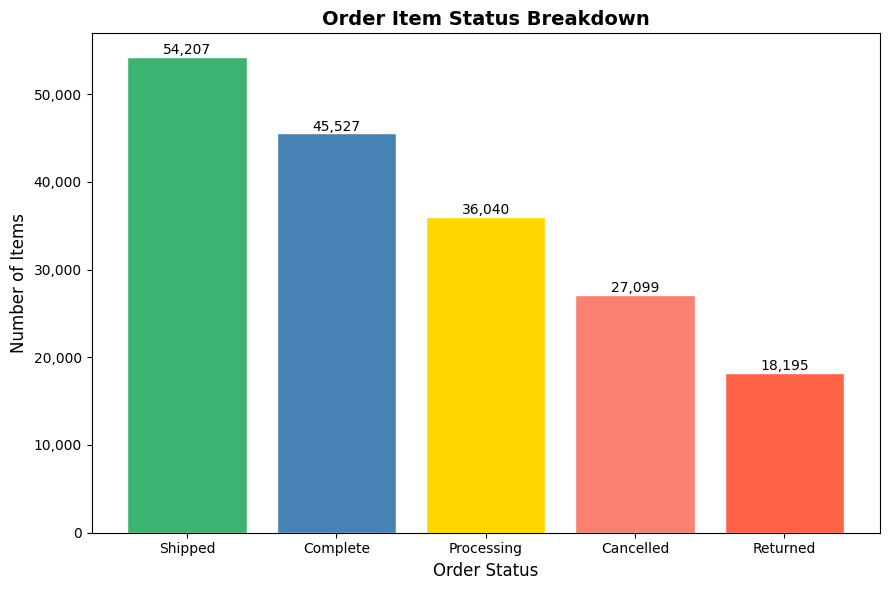

In [12]:
fig, ax = plt.subplots(figsize=(9, 6))
colors = {'Complete': 'steelblue', 'Shipped': 'mediumseagreen',
          'Processing': 'gold', 'Cancelled': 'salmon', 'Returned': 'tomato'}
bar_colors = [colors.get(s, 'grey') for s in order_breakdown.index]

bars = ax.bar(order_breakdown.index, order_breakdown.values, color=bar_colors, edgecolor='white')

# Add count labels on top of each bar
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'{bar.get_height():,.0f}', ha='center', fontsize=10)

ax.set_title('Order Item Status Breakdown', fontsize=14, fontweight='bold')
ax.set_xlabel('Order Status', fontsize=12)
ax.set_ylabel('Number of Items', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

### Finding: Nearly half of all order items never generate revenue

The order status breakdown reveals that only **Shipped (54,207)** and **Complete (45,527)** 
items represent realised revenue. The remaining statuses **Processing (36,040)**, 
**Cancelled (27,099)**, and **Returned (18,195)** account for ~45% of all order items 
and generate no revenue.

Cancelled and returned items alone represent ~25% of total volume, indicating meaningful 
fulfilment or product-fit issues worth investigating.

**Business implication:** Reducing the cancellation rate by even 5% would directly translate 
to revenue uplift. Identifying whether cancellations cluster in specific categories, countries, 
or traffic sources would be the first analytical step.

---
## Part 4: Geography & Acquisition

This section examines where revenue comes from geographically and which acquisition channels are most valuable, both in raw revenue and in the quality of customers they bring.

In [13]:
# Top 10 countries by realised revenue
# Note: source data has some duplicate country names (Deutschland/Germany, España/Spain)
# Only standardised English-language names are shown here
rev_country = (completed_orders
    .groupby('country')['sale_price']
    .agg(total_revenue='sum')
    .sort_values(by='total_revenue', ascending=False)
    .reset_index())
rev_country.index = range(1, len(rev_country) + 1)
rev_country.head(10)

,country,total_revenue
1,China,"2,012,751.50"
2,United States,"1,355,733.95"
3,Brasil,"863,551.49"
4,South Korea,"301,522.92"
5,France,"291,028.84"
6,United Kingdom,"264,995.04"
7,Germany,"242,014.77"
8,Spain,"235,304.18"
9,Japan,"142,701.14"
10,Australia,"131,156.04"


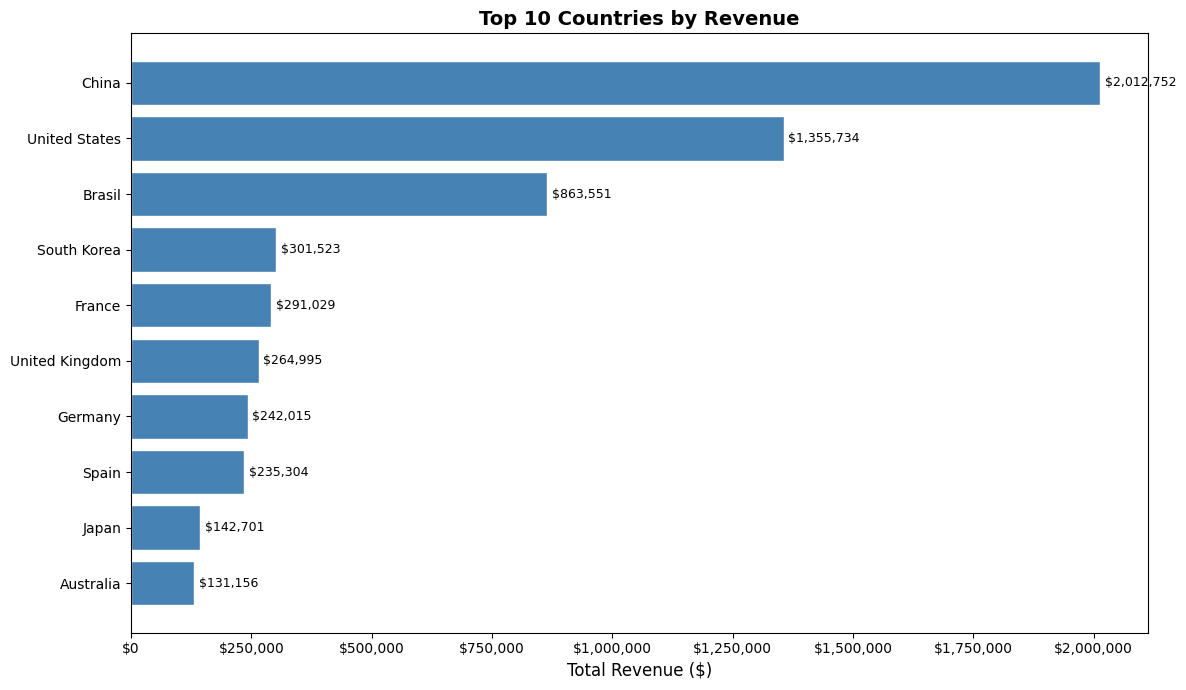

In [14]:
top10_countries = rev_country.head(10).sort_values('total_revenue', ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top10_countries['country'], top10_countries['total_revenue'],
               color='steelblue', edgecolor='white')

for bar in bars:
    ax.text(bar.get_width() + 10000, bar.get_y() + bar.get_height()/2,
            f'${bar.get_width():,.0f}', va='center', fontsize=9)

ax.set_title('Top 10 Countries by Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Revenue ($)', fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

### Finding: China and the US account for over half of total revenue

**China (2.01M)** and **United States (1.36M)** together represent the majority of realised revenue, with Brazil (864K) a distant third. The remaining markets (South Korea, France, UK, Germany, Spain, Japan, Australia) are clustered in the 130K–300K range.

**Business implication:** Revenue is highly geographically concentrated. Any market-specific disruption in China or the US (regulatory, logistics, macroeconomic) would have an outsized impact on total revenue. Diversification into the mid-tier markets would reduce this concentration risk.

**Note on data quality:** The source dataset contains duplicate country entries (e.g. `Deutschland` and `Germany`, `España` and `Spain`). In a production pipeline these would be normalised using a country standardisation lookup table. For this analysis, we use only the standardised English-language names.

In [15]:
# Revenue by acquisition/traffic source
rev_traffic = (completed_orders
    .groupby('traffic_source')['sale_price']
    .agg(total_revenue='sum')
    .sort_values(by='total_revenue', ascending=False)
    .reset_index())
rev_traffic.index = range(1, len(rev_traffic) + 1)
rev_traffic

,traffic_source,total_revenue
1,Search,"4,161,679.85"
2,Organic,"887,152.13"
3,Facebook,"357,872.92"
4,Email,"295,796.48"
5,Display,"229,806.72"


In [16]:
# Average customer LTV by traffic source
# This answers: which channel brings customers who spend the most over their lifetime?
# We merge fct_orders (has traffic_source) with dim_customers (has total_spend/LTV)
# drop_duplicates ensures each user is counted once per traffic source
traffic_ltv = (fct_orders[['user_id', 'traffic_source']]
    .drop_duplicates() # a user can appear under multiple traffic sources across orders; keep one row per user-channel pair
    .merge(dim_customers[['customer_id', 'total_spend']],
           left_on='user_id', right_on='customer_id', how='left')
    .groupby('traffic_source')
    .agg(avg_ltv=('total_spend', 'mean'))
    .sort_values(by='avg_ltv', ascending=False)
    .reset_index())
traffic_ltv

,traffic_source,avg_ltv
0,Email,74.98
1,Search,74.24
2,Organic,74.12
3,Facebook,73.59
4,Display,71.59


### Finding: Search dominates revenue volume, but all channels produce similar customer quality

**Search** generates ~4.16M in revenue, nearly 5x the next channel (Organic at 887K), 
reflecting its dominance as the primary acquisition channel.

However, average customer LTV across all channels is remarkably similar: Email leads at 
74.98, followed closely by Search (74.24), Organic (74.12), Facebook (73.59), and 
Display (71.59). The difference between the highest and lowest is less than 4.

**Business implication:** Since channel quality is roughly equal, marketing budget allocation 
should focus on cost-per-acquisition rather than LTV differences. Search's revenue dominance 
is a volume story, not a quality story. The business acquires many customers through Search, 
but those customers are not meaningfully more or less valuable than customers from other channels.

---
## Part 5: Customer Health

This section examines the health of the customer base: LTV distribution, top customers, churn, cohort retention, and revenue concentration. Together these paint a picture of how sustainable current growth is.

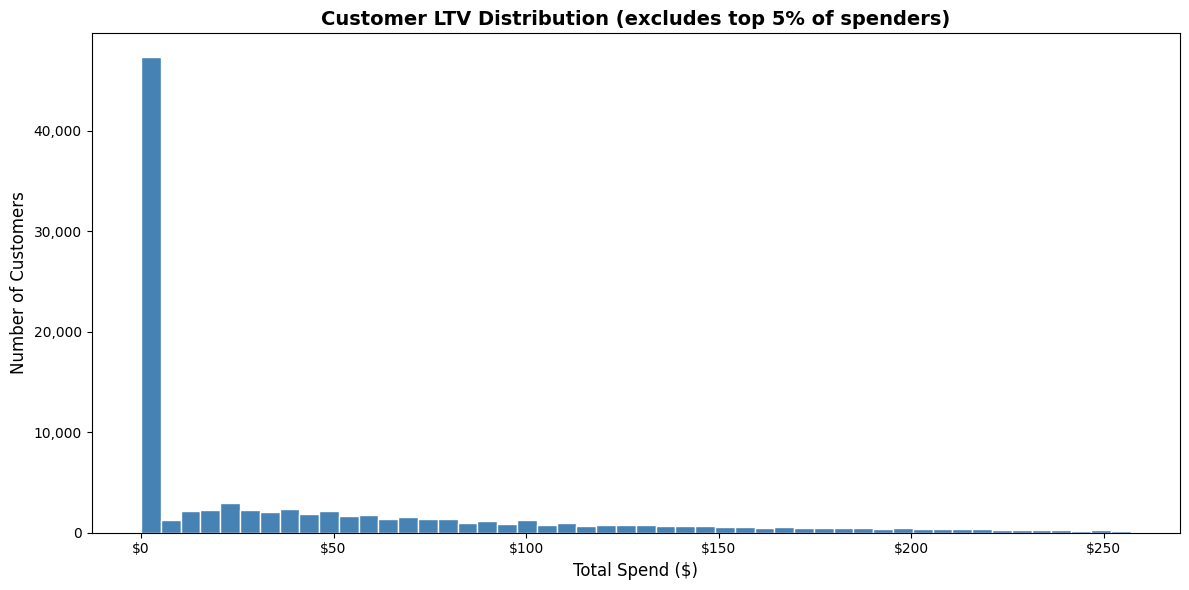

In [17]:
# LTV distribution (filtered to 95th percentile to remove outlier tail)
# The top 5% of spenders are real customers but would compress the x-axis
# making the distribution unreadable. They are noted separately below.
ltv_filtered = dim_customers[dim_customers['total_spend'] <= dim_customers['total_spend'].quantile(0.95)]

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(ltv_filtered['total_spend'], bins=50, color='steelblue', edgecolor='white')
ax.set_title('Customer LTV Distribution (excludes top 5% of spenders)', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Spend ($)', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

### Finding: LTV is heavily right-skewed, most customers are low-spend, a few drive outsized value

The distribution is strongly right-skewed, with the majority of customers clustering at low 
lifetime spend values and a long tail of high-value customers. This is the classic retail LTV 
pattern.

The large spike at $0 represents **47,180 customers** (47.2% of the total base) who have never 
placed an order. These are confirmed genuine zero-spend customers, `total_spend` has no NULLs 
in the mart, meaning `COALESCE` is applied correctly in `dim_customers.sql`. This segment showed 
enough intent to create an account but never converted.

**Business implication:** Nearly half the customer base has never purchased. Even a modest 
activation rate on this segment (say 5% converting with an average first order of 70) would 
represent ~165K in incremental revenue. Re-engagement campaigns with a first-purchase incentive 
are the highest-leverage intervention available.

In [18]:
# Top 10 customers by lifetime spend
top_customers = (dim_customers
    .sort_values('total_spend', ascending=False)
    [['customer_id', 'customer_name', 'total_spend']]
    .head(10)
    .reset_index(drop=True))
top_customers.index = range(1, 11)
top_customers

,customer_id,customer_name,total_spend
1,92275,Jose Walker,"1,521.90"
2,28167,James Ryan,"1,347.09"
3,66204,Kimberly Obrien,"1,291.49"
4,69520,Derek Gonzalez,"1,277.03"
5,39341,Ricky Guerrero,"1,277.00"
6,5477,Louis Buchanan,"1,259.38"
7,54704,Ryan Ortiz,"1,240.47"
8,4912,Christopher Lynch,"1,236.93"
9,65929,Kim Ward,"1,214.98"
10,98786,Tiffany Alexander,"1,198.03"


In [19]:
# Churn classification
# Churned: last order was more than 90 days ago
# Active: last order within the last 90 days
# No Orders: customer has never placed an order
# fillna(0) is used to avoid NA comparison issues in the inner np.where;
# the outer condition catches all null cases first
dim_customers['churn_status'] = np.where(
    dim_customers['days_since_last_order'].isnull(),
    'No Orders',
    np.where(dim_customers['days_since_last_order'].fillna(0) > 90, 'Churned', 'Active')
)

churn_summary = dim_customers['churn_status'].value_counts()
churn_summary

churn_status
Churned      63355
No Orders    19949
Active       16696
Name: count, dtype: int64

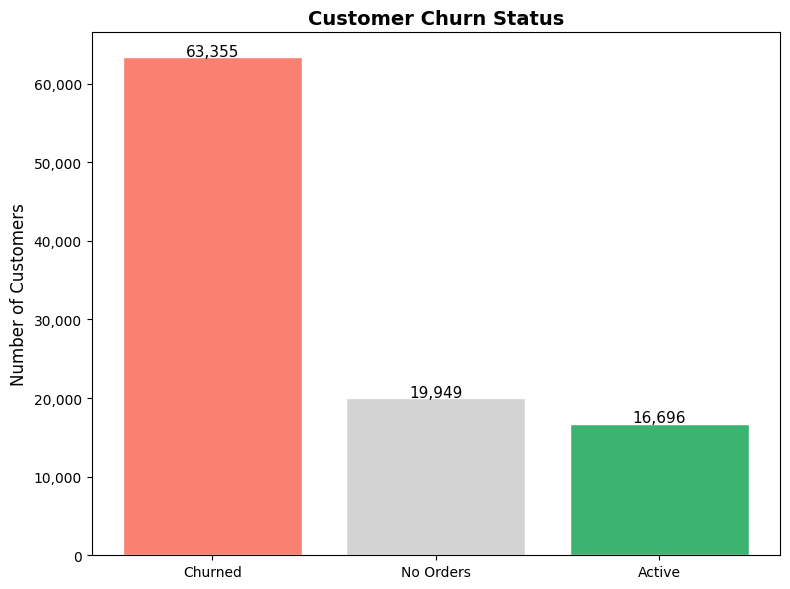

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = {'Active': 'mediumseagreen', 'Churned': 'salmon', 'No Orders': 'lightgrey'}
bar_colors = [colors.get(s, 'steelblue') for s in churn_summary.index]

bars = ax.bar(churn_summary.index, churn_summary.values, color=bar_colors, edgecolor='white')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{bar.get_height():,.0f}', ha='center', fontsize=11)

ax.set_title('Customer Churn Status', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Customers', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

### Finding: 63% of customers have churned, a significant retention problem

Of 100,000 customers: **63,355 have churned** (last order 90+ days ago), **19,949 have 
never placed an order**, and only **16,696 are active** (purchased within the last 90 days).

This means fewer than 1 in 6 customers is currently active.

**Business implication:** Two separate interventions are warranted:
1. **Re-engagement campaigns** for churned customers: personalised outreach based on prior 
purchase category
2. **Activation campaigns** for never-ordered customers: these users showed enough interest 
to create an account; converting even a fraction would materially grow the active base

### Cohort Retention Analysis

Cohort analysis groups customers by the month of their **first purchase** and tracks what percentage return in subsequent months. This is the gold standard metric for measuring whether the business retains the customers it acquires.

**How to read the heatmap:** Month 0 is always 100% (the cohort baseline). Month 1 shows what % returned the following month, Month 2 the month after that, etc. Darker blue = higher retention.

In [21]:
# Build cohort retention matrix
# Join completed_orders with dim_customers to get first_order_date per customer
# Then calculate how many months after their first order each subsequent order occurred
combined = pd.merge(completed_orders, dim_customers, left_on='user_id', right_on='customer_id')
combined['cohort'] = combined['first_order_date'].dt.to_period('M')
# Convert periods to int and subtract to get the month offset from cohort start
# e.g. if first order was 2024-01 and this order is 2024-03, cohort_month = 2
combined['cohort_month'] = (
    combined['created_at'].dt.to_period('M').astype(int) -
    combined['first_order_date'].dt.to_period('M').astype(int)
)

# Remove negative cohort months, caused by created_at being slightly before first_order_date
# (a data quality artefact in this synthetic dataset)
combined = combined[combined['cohort_month'] >= 0]

# Focus on 2024 onwards for a readable heatmap, earlier cohorts have sparse recent data
combined = combined[combined['cohort'] >= '2024-01']

# Count distinct customers per cohort per month offset
cohort = combined.groupby(['cohort', 'cohort_month'])['user_id'].nunique().reset_index()

# Pivot to matrix shape and limit to first 12 months
cohort_pivot = (cohort
    .pivot(index='cohort', columns='cohort_month', values='user_id')
    .fillna(0)
    .astype(int))
cohort_pivot = cohort_pivot.iloc[:, :12]

# Convert to retention % relative to cohort size (month 0)
cohort_sizes = cohort_pivot[0]
cohort_pct = cohort_pivot.divide(cohort_sizes, axis=0).round(3) * 100

C:\Users\luand\AppData\Local\Temp\ipykernel_30428\867821167.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  combined['cohort'] = combined['first_order_date'].dt.to_period('M')
C:\Users\luand\AppData\Local\Temp\ipykernel_30428\867821167.py:9: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  combined['created_at'].dt.to_period('M').astype(int) -
C:\Users\luand\AppData\Local\Temp\ipykernel_30428\867821167.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  combined['first_order_date'].dt.to_period('M').astype(int)


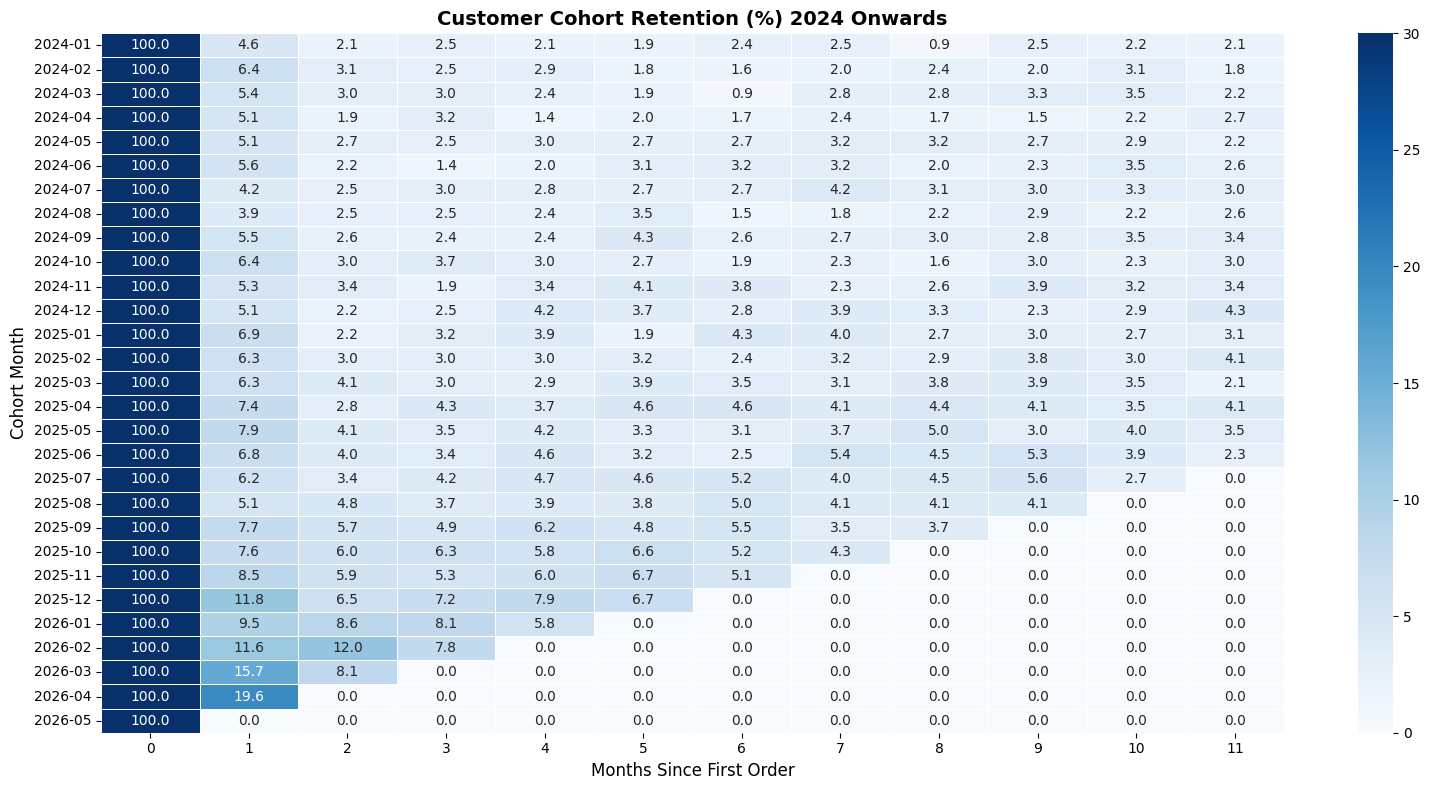

In [22]:
plt.figure(figsize=(16, 8))
sns.heatmap(cohort_pct,
            annot=True,
            fmt='.1f',
            cmap='Blues',
            vmin=0, vmax=30,
            linewidths=0.5)

plt.title('Customer Cohort Retention (%) 2024 Onwards', fontsize=14, fontweight='bold')
plt.xlabel('Months Since First Order', fontsize=12)
plt.ylabel('Cohort Month', fontsize=12)
plt.tight_layout()
plt.show()

### Finding: Retention is low in early cohorts but improving sharply in recent ones

Month-1 retention for 2024 cohorts sits in the **4-7% range**, meaning fewer than 1 in 14 
customers who made a first purchase returned the following month. However, this improves 
significantly through 2025-2026, with month-1 retention reaching **12-20%** by early 2026 
(2026-03: 15.7%, 2026-04: 19.6%).

This is a strong positive signal, recent cohorts are meaningfully more engaged than older ones.

**Business implication:** The improving retention trend suggests the product or post-purchase 
experience has improved over time. Identifying what changed between 2024 and 2026 and 
doubling down on those changes would be the highest-priority question for a retention team.

### Revenue Concentration Pareto Analysis

The Pareto principle (80/20 rule) in retail states that a small fraction of customers often drives a disproportionate share of revenue. This analysis quantifies that concentration for this business.

In [23]:
# What % of total revenue comes from the top 10% of customers by LTV?
# Both numerator and denominator use dim_customers.total_spend for consistency
# (total_spend only includes completed + shipped orders per the mart SQL)
threshold = dim_customers['total_spend'].quantile(0.90)
top_10_pct = dim_customers[dim_customers['total_spend'] >= threshold]
top_customers_sum = top_10_pct['total_spend'].sum()
total_revenue = dim_customers['total_spend'].sum()
revenue_concentration = top_customers_sum / total_revenue * 100
print(f"Top 10% of customers account for {revenue_concentration:.2f}% of total revenue")

Top 10% of customers account for 50.71% of total revenue


### Finding: Top 10% of customers drive 50.71% of revenue, a textbook Pareto distribution

The top 10% of customers by lifetime spend account for **50.71%** of total realised revenue. This is consistent with, and actually slightly better than, the classic 80/20 rule, suggesting the customer base is not excessively concentrated.

**Business implication:** This concentration level is healthy but warrants a dedicated high-value customer retention programme. Losing even a small fraction of the top-10% segment would have an outsized revenue impact. Strategies to consider:
- VIP loyalty tiers for customers above the 90th percentile spend threshold
- Proactive churn prevention for high-LTV customers showing declining purchase frequency
- Personalised assortment recommendations based on past high-spend category behaviour

---
## Summary of Key Findings

| Area | Finding | Implication |
|------|---------|-------------|
| **Product** | Outerwear & Coats + Jeans = top revenue categories | Prioritise inventory and promotions here |
| **Growth** | Consistent upward revenue trend 2019–2026, accelerating in 2025–2026 | Business in strong growth phase |
| **Operations** | ~25% of order items are cancelled or returned | High-priority investigation needed |
| **Geography** | China + US = majority of revenue | High geographic concentration risk |
| **Acquisition** | Search drives 70%+ of revenue volume; all channels produce near-identical avg LTV (~$72-75) | Optimise by cost-per-acquisition, not LTV |
| **Customers** | LTV is right-skewed; large never-ordered and churned segments | Re-engagement and activation campaigns warranted |
| **Retention** | Month-1 retention 4-7% in 2024, improving to 12-20% by early 2026 | Strong positive trend; first 30 days post-purchase is critical |
| **Concentration** | Top 10% of customers = 50.71% of revenue | Build VIP retention programme around this segment |

---

---

## Export: HTML Report

Exports the full analysis as a self-contained HTML file using a Jinja2 template. All charts are embedded as base64 PNGs, no external dependencies required to open the file.

---

In [24]:
# Export analysis as a self-contained HTML report using Jinja2
# Embeds all charts as base64 PNGs so the file is fully portable (no external dependencies)
import base64
import io
from jinja2 import Template
from datetime import datetime

def fig_to_base64(fig):
    """Convert a matplotlib figure to a base64-encoded PNG string for HTML embedding."""
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=150, bbox_inches='tight')
    buf.seek(0)
    return base64.b64encode(buf.read()).decode('utf-8')

# Re-render each chart into a figure object so we can capture them for the report
# --- Chart 1: Top 10 categories ---
fig1, ax = plt.subplots(figsize=(12, 7))
top10 = rev_product_category.head(10).sort_values('total_revenue', ascending=True)
bars = ax.barh(top10['category'], top10['total_revenue'], color='steelblue', edgecolor='white')
for bar in bars:
    ax.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
            f'${bar.get_width():,.0f}', va='center', fontsize=9)
ax.set_title('Top 10 Product Categories by Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Revenue ($)', fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
img_categories = fig_to_base64(fig1)
plt.close(fig1)

# --- Chart 2: Monthly revenue trend ---
fig2, ax1 = plt.subplots(figsize=(18, 6))
ax1.plot(rev_month_year['date'], rev_month_year['monthly_revenue'],
         color='steelblue', linewidth=2, marker='o', markersize=4, label='Monthly Revenue')
ax1.set_ylabel('Monthly Revenue ($)', color='steelblue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2 = ax1.twinx()
ax2.plot(rev_month_year['date'], rev_month_year['MoM_growth'],
         color='coral', linewidth=2, linestyle='--', marker='s', markersize=4, label='MoM Growth %')
ax2.set_ylabel('MoM Growth (%)', color='coral', fontsize=12)
ax2.tick_params(axis='y', labelcolor='coral')
ax2.axhline(y=0, color='coral', linestyle=':', alpha=0.5)
ax1.set_xlabel('Month', fontsize=12)
fig2.autofmt_xdate(rotation=45)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)
plt.title('Monthly Revenue Trend & MoM Growth %', fontsize=14, fontweight='bold')
plt.tight_layout()
img_revenue_trend = fig_to_base64(fig2)
plt.close(fig2)

# --- Chart 3: Cohort retention heatmap ---
fig3, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(cohort_pct, annot=True, fmt='.1f', cmap='Blues',
            vmin=0, vmax=30, linewidths=0.5, ax=ax)
ax.set_title('Customer Cohort Retention (%) 2024 Onwards', fontsize=14, fontweight='bold')
ax.set_xlabel('Months Since First Order', fontsize=12)
ax.set_ylabel('Cohort Month', fontsize=12)
plt.tight_layout()
img_cohort = fig_to_base64(fig3)
plt.close(fig3)

print("Charts rendered and encoded.")

Charts rendered and encoded.


In [25]:
# Jinja2 HTML report template
# Uses inline base64 images, no external files needed
REPORT_TEMPLATE = """
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>E-Commerce Sales Intelligence Report</title>
    <style>
        body { font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', sans-serif;
               max-width: 1200px; margin: 0 auto; padding: 40px 24px;
               color: #1a1a2e; background: #f8f9fa; }
        h1   { font-size: 2rem; color: #16213e; border-bottom: 3px solid #4a90d9;
               padding-bottom: 12px; }
        h2   { font-size: 1.3rem; color: #16213e; margin-top: 40px; }
        .meta { color: #666; font-size: 0.9rem; margin-bottom: 32px; }
        .kpi-grid { display: grid; grid-template-columns: repeat(auto-fit, minmax(200px, 1fr));
                    gap: 16px; margin: 24px 0 40px; }
        .kpi  { background: white; border-radius: 8px; padding: 20px;
                box-shadow: 0 2px 8px rgba(0,0,0,.08); }
        .kpi-value { font-size: 1.8rem; font-weight: 700; color: #4a90d9; }
        .kpi-label { font-size: 0.85rem; color: #666; margin-top: 4px; }
        .chart-wrap { background: white; border-radius: 8px; padding: 24px;
                      box-shadow: 0 2px 8px rgba(0,0,0,.08); margin: 24px 0; }
        .chart-wrap img { width: 100%; height: auto; }
        table { width: 100%; border-collapse: collapse; background: white;
                border-radius: 8px; overflow: hidden;
                box-shadow: 0 2px 8px rgba(0,0,0,.08); margin: 24px 0; }
        th    { background: #16213e; color: white; padding: 12px 16px;
                text-align: left; font-size: 0.85rem; }
        td    { padding: 10px 16px; border-bottom: 1px solid #f0f0f0; font-size: 0.9rem; }
        tr:last-child td { border-bottom: none; }
        tr:hover td { background: #f8f9fa; }
        .note { background: #fff8e1; border-left: 4px solid #ffc107;
                padding: 12px 16px; border-radius: 0 6px 6px 0;
                font-size: 0.9rem; margin: 16px 0; }
        footer { margin-top: 60px; padding-top: 20px; border-top: 1px solid #ddd;
                 font-size: 0.8rem; color: #999; }
    </style>
</head>
<body>

<h1>E-Commerce Sales Intelligence Report</h1>
<p class="meta">Generated: {{ generated_at }} &nbsp;|&nbsp; Source: bigquery-public-data.thelook_ecommerce &nbsp;|&nbsp; Pipeline: BigQuery → dbt → Python</p>

<div class="kpi-grid">
    <div class="kpi"><div class="kpi-value">${{ total_revenue }}</div><div class="kpi-label">Total Realised Revenue</div></div>
    <div class="kpi"><div class="kpi-value">{{ total_customers }}</div><div class="kpi-label">Total Customers</div></div>
    <div class="kpi"><div class="kpi-value">{{ active_customers }}</div><div class="kpi-label">Active Customers (90d)</div></div>
    <div class="kpi"><div class="kpi-value">{{ revenue_concentration }}%</div><div class="kpi-label">Revenue from Top 10% Customers</div></div>
</div>

<div class="note">All revenue figures exclude Cancelled, Returned, and Processing order items.</div>

<h2>Top 10 Product Categories by Revenue</h2>
<div class="chart-wrap"><img src="data:image/png;base64,{{ img_categories }}" alt="Top 10 categories chart"></div>

<h2>Monthly Revenue Trend &amp; MoM Growth %</h2>
<div class="chart-wrap"><img src="data:image/png;base64,{{ img_revenue_trend }}" alt="Monthly revenue trend chart"></div>

<h2>Customer Cohort Retention (2024 Onwards)</h2>
<div class="chart-wrap"><img src="data:image/png;base64,{{ img_cohort }}" alt="Cohort retention heatmap"></div>

<h2>Summary of Key Findings</h2>
<table>
    <tr><th>Area</th><th>Finding</th><th>Implication</th></tr>
    {% for row in summary_rows %}
    <tr><td><strong>{{ row.area }}</strong></td><td>{{ row.finding }}</td><td>{{ row.implication }}</td></tr>
    {% endfor %}
</table>

<footer>E-Commerce Sales Intelligence Pipeline &mdash; TheLook E-Commerce Dataset</footer>
</body>
</html>
"""

# Populate template variables from computed values
active_count = int((dim_customers['churn_status'] == 'Active').sum())

summary_rows = [
    {"area": "Product",       "finding": "Outerwear & Coats + Jeans = top revenue categories",                         "implication": "Prioritise inventory and promotions here"},
    {"area": "Growth",        "finding": "Consistent upward trend 2019–2026, accelerating in 2025–2026",               "implication": "Business in strong growth phase"},
    {"area": "Operations",    "finding": "~25% of order items are cancelled or returned",                               "implication": "High-priority investigation needed"},
    {"area": "Geography",     "finding": "China + US = majority of revenue",                                           "implication": "High geographic concentration risk"},
    {"area": "Acquisition",   "finding": "Search drives 70%+ of volume; all channels produce near-identical avg LTV",  "implication": "Optimise by cost-per-acquisition, not LTV"},
    {"area": "Customers",     "finding": "LTV is right-skewed; large never-ordered and churned segments",              "implication": "Re-engagement and activation campaigns warranted"},
    {"area": "Retention",     "finding": "Month-1 retention 4–7% in 2024, improving to 12–20% by early 2026",         "implication": "First 30 days post-purchase is critical window"},
    {"area": "Concentration", "finding": f"Top 10% of customers = {revenue_concentration:.2f}% of revenue",           "implication": "Build VIP retention programme around this segment"},
]

template = Template(REPORT_TEMPLATE)
html_output = template.render(
    generated_at=datetime.now().strftime("%Y-%m-%d %H:%M"),
    total_revenue=f"{total_revenue:,.0f}",
    total_customers=f"{len(dim_customers):,}",
    active_customers=f"{active_count:,}",
    revenue_concentration=f"{revenue_concentration:.2f}",
    img_categories=img_categories,
    img_revenue_trend=img_revenue_trend,
    img_cohort=img_cohort,
    summary_rows=summary_rows,
)

report_path = "sales_intelligence_report.html"
with open(report_path, "w", encoding="utf-8") as f:
    f.write(html_output)

print(f"Report written to: {report_path}")

Report written to: sales_intelligence_report.html


### Next Steps (Post-Upskilling Enhancements)
- **LLM-generated executive summary** via Anthropic API: replace this static summary with a dynamically generated narrative based on the actual numbers
- **FastAPI endpoint**: trigger the full pipeline on demand via HTTP POST
- **LangChain Q&A**: allow natural language questions over this dataset
- **Make.com automation**: weekly pipeline run with automated HTML report delivery